# Deep Learning for Computer Vision

## Project 1 - Image Classification

**Authors:** António Cruz (140129), David Isaac (120064), Erik Daskalyuk (120062), Ivan Magalhães (106586), Ricardo Pereira (120052)

**Date:** 2025-11-09

# 0. Project Scope and Objectives

---

## Scope

This project focuses on developing an AI classification model to automatically analyze chest X-ray images and identify patients with a history of pneumonia. The solution leverages deep learning techniques to design, train and validate a convolutional neural network optimized for high recall, reflecting the clinical priority of not missing pneumonia cases.

Through systematic experimentation with the model architecture and training configuration, the project evaluates different design choices (such as the number of convolutional filters, the use of Batch Normalization, Dropout and L2 regularization, and the learning rate strategy) and selects a final model that performs reliably on a held-out test set. Particular emphasis is placed on understanding how the decision threshold affects recall, precision and the pattern of false negatives and false positives.

The system will:

* Process and classify chest X-ray images into two categories: Normal and Pneumonia.
* Enable the hospital to proactively identify at-risk patients for targeted awareness and preventive care in a retrospective screening setting.

## Objectives

1. Develop a baseline model
   Implement an initial convolutional neural network for binary classification of chest X-ray images, providing a reference point for subsequent improvements.

2. Optimize model architecture and training configuration
   Refine the network structure (number of filters, pooling strategy, dense head) and training setup (optimizer, learning rate, class weights) to improve performance while keeping the model relatively simple and interpretable.

3. Implement regularization and stabilization techniques
   Apply L2 regularization, Batch Normalization, Dropout, class weighting, early stopping and learning rate scheduling to reduce overfitting and improve generalization to unseen data.

4. Evaluate and interpret model performance
   Assess the final model using metrics such as accuracy, AUC, PR-AUC, precision, recall and F1-score, analyze confusion matrices and threshold-dependent behavior, and justify the choice of the recommended operating threshold.

5. Deliver a functional and documented solution
   Provide a well-documented Python codebase and a report detailing the dataset, methodology, model architecture, training process, evaluation results and rationale behind the selected model and threshold strategy.

Overall, the project aims to deliver a practical and recall-focused AI model that can assist healthcare professionals in the retrospective identification of patients with pneumonia history, supporting early preventive interventions and reduction of recurrence risk.

# 1. Introduction

---

This project addresses the healthcare challenge of identifying patients with a history of pneumonia from historical X-ray records, enabling targeted preventive care and reducing recurrence risk. Using Python and deep learning libraries, we developed a binary classification model explicitly optimized for high recall, prioritizing the detection of true pneumonia cases over minimizing false positives. This design aligns with the hospital’s goal of secondary prevention, where missing vulnerable patients (false negatives) poses a greater risk than contacting healthy individuals (false positives).

The solution integrates data preprocessing, convolutional neural network design and systematic performance evaluation, with an emphasis on flexibility and robustness. In particular, the model is designed to support post-training threshold adjustments, allowing the hospital to choose operating points that balance recall and precision according to operational needs, from more comprehensive coverage to more resource-efficient outreach.

## 1.1 Environment Setup

The project uses the following key libraries:

* Scikit-learn: for evaluation and metric computation, including F1-score, confusion matrices and classification reports.
* Keras and TensorFlow: for model definition, training and optimization, including layers, regularizers, callbacks and custom metrics.
* Matplotlib, NumPy and Seaborn: for data visualization, analysis and exploratory data understanding.

In the following sections, we describe the dataset and preprocessing pipeline, then present the model architecture, training procedure, evaluation strategy and final conclusions.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight as sk_class_weight

import tensorflow as tf
from keras import Input, models, layers, regularizers
from keras.callbacks import ModelCheckpoint
from keras.utils import image_dataset_from_directory
from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import EarlyStopping
from keras.optimizers import AdamW
from keras.metrics import AUC, Precision, Recall

2025-11-10 18:11:24.270149: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 18:11:24.529706: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 18:11:25.550625: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
# Global configuration
SEED = 42                                        # Fixed random seed for reproducibility
BATCH_SIZE = 32                                  # Number of images per training batch
LEARNING_RATE = 1e-4                             # Initial learning rate for the optimizer
CHECKPOINT_PATH = "best_model_checkpoint.keras"  # File path to save the best model

# Set random seeds for reproducibility across libraries
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. Data Understanding

---

## 2.1 Dataset Overview

The Chest X-Ray Images (Pneumonia) dataset is a widely used medical imaging dataset curated for the detection and classification of pneumonia from chest X-ray images. It was originally made available by Daniel Kermany et al. (2018) on Kaggle and is derived from pediatric patients (aged approximately 1–5 years) treated at the Guangzhou Women and Children’s Medical Center.

This dataset is intended to support research in medical image analysis, especially for developing and evaluating deep learning models for automated pneumonia detection. In this project, the images are converted to standardized grayscale inputs of 256×256 pixels, and separate subsets are constructed for training, validation and testing to allow for fair performance estimation on unseen data.

## 2.2 Data Description

The dataset contains chest X-ray images categorized into two primary classes:

* Normal: X-ray scans of patients with no radiological signs of pneumonia.
* Pneumonia: X-ray scans showing lung opacities consistent with pneumonia.

Within the Pneumonia label, the original dataset distinguishes two subcategories:

* Bacterial pneumonia
* Viral pneumonia

For the purposes of this project, these subcategories are treated as a single Pneumonia class, since the clinical objective is to identify patients with a history of pneumonia in general, regardless of the specific etiology.

## 2.3 Data Characteristics

* Format: JPEG chest X-ray images
* Classes: 2 (Normal, Pneumonia)
* Label encoding used in this project:

  * 0 → Normal
  * 1 → Pneumonia

All images are loaded in grayscale mode and resized to a fixed resolution of 256×256 pixels before being fed to the model, ensuring consistent input shape across the dataset.

## 2.4 Data Processing

In [4]:
# Set paths for train and test datasets
train_dir = "../chest_xray/train"
test_dir = "../chest_xray/test"

In [5]:
# Parameters
batch_size = BATCH_SIZE
img_size = (256, 256)

In [6]:
# Load datasets first without batching
train_dataset_unbatched = image_dataset_from_directory(
	train_dir,
	labels='inferred',
	label_mode='int',
	image_size=img_size,
	color_mode='grayscale',
	batch_size=None,
	shuffle=False,
	class_names=['NORMAL','PNEUMONIA']
)

test_dataset_unbatched = image_dataset_from_directory(
	test_dir,
	labels='inferred',
	label_mode='int',
	image_size=img_size,
	color_mode='grayscale',
	batch_size=None,
	shuffle=False,
	class_names=['NORMAL','PNEUMONIA']
)

# Convert to grayscale
# (loaded directly as grayscale above)
train_dataset_gray = train_dataset_unbatched.cache()
test_dataset_gray = test_dataset_unbatched.cache()

Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


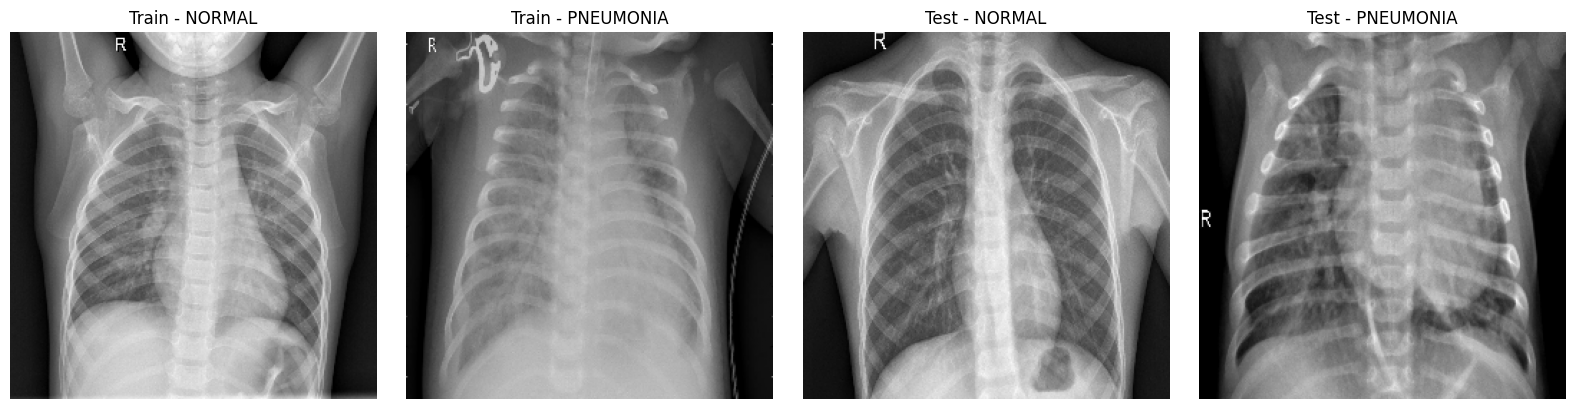

In [7]:
# Helper function to extract one image by class label
def get_example_by_label(dataset, label):
    for image, lbl in dataset:
        if lbl.numpy() == label:
            return image.numpy().squeeze(), lbl.numpy()
    return None, None

# Get one NORMAL (0) and one PNEUMONIA (1) image from train and test sets
train_normal_img, _ = get_example_by_label(train_dataset_unbatched, 0)
train_pneumonia_img, _ = get_example_by_label(train_dataset_unbatched, 1)
test_normal_img, _ = get_example_by_label(test_dataset_unbatched, 0)
test_pneumonia_img, _ = get_example_by_label(test_dataset_unbatched, 1)

# Plot all 4 images in a single row
plt.figure(figsize=(16, 4))

titles = [
    'Train - NORMAL',
    'Train - PNEUMONIA',
    'Test - NORMAL',
    'Test - PNEUMONIA'
]

images = [
    train_normal_img,
    train_pneumonia_img,
    test_normal_img,
    test_pneumonia_img
]

for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

**Figure 1** - Chest X-ray examples from the training and test sets (NORMAL and PNEUMONIA classes).

To gain a deeper understanding of the model's performance, it's essential to analyze the weight distribution of each class across the entire dataset.

In [8]:
# Collect labels from the training dataset
all_labels = []

for _, y in train_dataset_gray:   # or train_dataset if you've already split
	y_np = y.numpy().astype("int32").ravel()
	all_labels.extend(y_np.tolist())

all_labels = np.array(all_labels)

classes = np.array([0, 1])

# Compute balanced class weights
class_weights_array = sk_class_weight.compute_class_weight(
	class_weight="balanced",
	classes=classes,
	y=all_labels
)

# Put them in a dict for Keras
class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, class_weights_array)}

print("Class counts:", {c: int((all_labels == c).sum()) for c in classes})
print("Class weights:", class_weight_dict)

Class counts: {np.int64(0): 1349, np.int64(1): 3883}
Class weights: {0: 1.939214232765011, 1: 0.6737058975019315}


2025-11-10 18:12:13.514019: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In the following plot, the weight distribution across each class in the dataset is clearly shown. The dataset consists of 26% images of the NORMAL class and 74% images of the PNEUMONIA class.

This class imbalance could negatively impact model performance, as the model may become biased toward classifying images as PNEUMONIA, potentially leading to poorer performance on the NORMAL class.

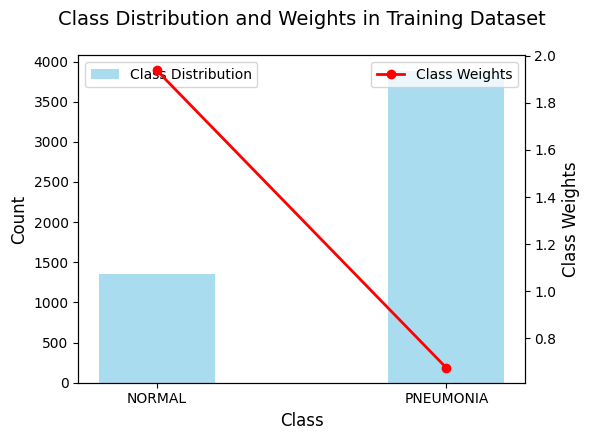

In [ ]:
# Prepare data for plotting
classes = ['NORMAL', 'PNEUMONIA']
class_indices = [0, 1]

# Compute counts from all_labels
class_counts = {c: int((all_labels == c).sum()) for c in class_indices}
counts = [class_counts[0], class_counts[1]]

# Extract weights from dict
weights = [class_weight_dict[0], class_weight_dict[1]]

# Plotting (unchanged)
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))

ax1.bar(
	classes,
	counts,
	color='skyblue',
	alpha=0.7,
	label="Class Distribution",
	width=0.4,
	align='center'
)

ax2 = ax1.twinx()
ax2.plot(
	classes,
	weights,
	color='red',
	marker='o',
	label="Class Weights",
	linewidth=2
)

ax1.set_title('Class Distribution and Weights in Training Dataset\n', fontsize=14)
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax2.set_ylabel('Class Weights', fontsize=12)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Figure 2** - Class distribution and corresponding training weights for NORMAL and PNEUMONIA in the training dataset.

In this step, we split the training data to create a validation set, allowing us to monitor and evaluate the model's performance throughout the training process.

In [10]:
# After the class_weight cell where you built all_labels
total = len(all_labels)  # number of samples in train_dataset_gray

# Shuffle and split 10% validation
val_samples = int(0.10 * total)

shuffled_dataset = train_dataset_gray.shuffle(
	buffer_size=min(total, 10_000),
	seed=SEED,
	reshuffle_each_iteration=False  # stable split
)

val_dataset = shuffled_dataset.take(val_samples)
train_dataset = shuffled_dataset.skip(val_samples)

In [11]:
# Define normalization
def normalize_images(images, labels):
	images = tf.math.truediv(tf.cast(images, tf.float32), 255.0)
	return images, labels

We apply normalization to each dataset in order to enhance model generalization and improve its robustness during training.

In [12]:
# Normalize all the splits
train_dataset = train_dataset.map(
	normalize_images, num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset = val_dataset.map(
	normalize_images, num_parallel_calls=tf.data.AUTOTUNE
)
test_dataset_gray = test_dataset_gray.map(
	normalize_images, num_parallel_calls=tf.data.AUTOTUNE
)

We prepare the datasets for training and evaluation by batching and prefetching the data using the `tf.data` API.

* Batching:
  The training, validation and test datasets are batched with the chosen `batch_size`, so that examples are grouped into manageable chunks for efficient processing on the GPU/CPU. In this step:

  * `train_for_fit_dataset`, `val_dataset_gray` and `test_dataset_gray` are all converted into batched datasets.

* Prefetching:
  To improve performance, we call `.prefetch(tf.data.AUTOTUNE)` on each dataset. This allows the input pipeline to prepare the next batch in the background while the model is training or evaluating on the current batch, reducing idle time and improving throughput.

After batching and prefetching, we validate the setup by inspecting one batch from the training and validation datasets, checking the batch shapes and the range of pixel values. This confirms that the data is being fed to the model with the expected dimensions and normalization.

In [13]:
# Batch
train_for_fit_dataset = train_dataset.batch(batch_size)
val_dataset_gray = val_dataset.batch(batch_size)
test_dataset_gray = test_dataset_gray.batch(batch_size)

# Prefetch for performance
train_for_fit_dataset = train_for_fit_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset_gray = val_dataset_gray.prefetch(tf.data.AUTOTUNE)
test_dataset_gray = test_dataset_gray.prefetch(tf.data.AUTOTUNE)

In [14]:
# Validate setup
print("\n=== Dataset Verification ===")
for images, labels in train_for_fit_dataset.take(1):
	print(f"Training batch shape: {images.shape}")
	print(f"Training labels shape: {labels.shape}")
	print(f"Training image range: [{tf.reduce_min(images):.3f}, {tf.reduce_max(images):.3f}]")

for images, labels in val_dataset_gray.take(1):
	print(f"Validation batch shape: {images.shape}")
	print(f"Validation labels shape: {labels.shape}")
	print(f"Validation image range: [{tf.reduce_min(images):.3f}, {tf.reduce_max(images):.3f}]")


=== Dataset Verification ===
Training batch shape: (32, 256, 256, 1)
Training labels shape: (32,)
Training image range: [0.000, 1.000]
Validation batch shape: (32, 256, 256, 1)
Validation labels shape: (32,)
Validation image range: [0.000, 1.000]


2025-11-10 18:12:37.528077: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# 3. Training

---

## 3.1 Training Configuration and Callbacks

In this section, we build and train a Convolutional Neural Network (CNN) to classify chest X-ray images into two categories: Normal and Pneumonia. The model is trained on the preprocessed grayscale dataset using the AdamW optimizer, L2 regularization, Batch Normalization and Dropout. To improve generalization and avoid overfitting, we use three Keras callbacks: ModelCheckpoint, EarlyStopping and ReduceLROnPlateau.

ModelCheckpoint and EarlyStopping monitor the validation PR-AUC (`val_pr_auc`), which is well suited for imbalanced problems and directly reflects the balance between precision and recall. ReduceLROnPlateau monitors the validation loss (val_loss) and reduces the learning rate when progress stalls, helping the optimizer make finer updates later in training.

The main callback parameters used in this project are summarized below.

**Table 1** – Model callback parameter descriptions

| Parameter              | Meaning                                                                                                                                                                                |
| :--------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `monitor`              | Metric being tracked to decide whether there is an improvement. In this project: `val_pr_auc` for model checkpointing and early stopping, and `val_loss` for learning rate scheduling. |
| `patience`             | Number of epochs to wait without improvement in the monitored metric before stopping or reducing the learning rate.                                                                    |
| `mode`                 | Direction of optimization for the monitored metric. For `val_pr_auc` we use `"max"` (higher is better); for `val_loss` we use `"min"` (lower is better).                               |
| `save_best_only`       | When `True`, only saves the checkpoint corresponding to the best observed value of the monitored metric.                                                                               |
| `save_weights_only`    | When `False`, saves the full model (architecture and weights) instead of just the weights.                                                                                             |
| `verbose`              | Controls how much logging is printed during training when the callback is triggered.                                                                                                   |
| `restore_best_weights` | When `True`, restores the model weights from the epoch with the best monitored metric after early stopping.                                                                            |
| `min_lr`               | Minimum learning rate allowed by the scheduler; prevents the learning rate from being reduced too far.                                                                                 |
| `factor`               | Multiplicative factor used to reduce the learning rate when the monitored metric stops improving.                                                                                      |

## 3.2 Model Checkpoint Saving

We set up a callback to save the best model during training based on validation PR-AUC rather than raw accuracy. This is more appropriate for an imbalanced, clinically oriented problem where the balance between precision and recall is more important than overall accuracy.

The ModelCheckpoint callback:

* Saves the model to the file path defined by `CHECKPOINT_PATH`.
* Monitors the `val_pr_auc` metric on the validation set.
* Keeps only the model corresponding to the highest observed `val_pr_auc` during training.

By saving the best validation-PR-AUC checkpoint instead of simply using the weights from the final epoch, we reduce the risk of overfitting. If performance on the validation set starts to degrade after a certain point, we still retain the version of the model that showed the best generalization according to the chosen metric.

In [14]:
# Best model checkpoint saving
best_model_callback = ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor="val_pr_auc",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

## 3.3 Early Stopping

We also use an EarlyStopping callback to automatically stop training when further epochs no longer improve the model’s performance on the validation set.

In this project:

* EarlyStopping monitors the validation PR-AUC (`val_pr_auc`), not the training metrics.
* If `val_pr_auc` does not improve for a specified number of epochs (the patience value), training is stopped.
* With `restore_best_weights=True`, the model weights are rolled back to those from the epoch with the highest `val_pr_auc`.

This prevents wasting epochs once the model has effectively converged and reduces overfitting by avoiding continued training after validation performance has stopped improving, while still keeping the best-performing version of the model for subsequent evaluation.

In [15]:
# Early stopping
early_stopping = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

## 3.4 Learning Rate

The learning rate is a key hyperparameter that controls how much the model weights are updated during training. If it is too high, the optimizer may overshoot good minima and converge to a suboptimal solution; if it is too low, training can become very slow or get stuck.

In this project, we use the AdamW optimizer with an initial learning rate defined by `LEARNING_RATE`, together with a learning rate scheduler based on the `ReduceLROnPlateau` callback. The scheduler:

* Monitors the validation loss (`val_loss`).
* If `val_loss` does not improve for a certain number of epochs (patience), it reduces the learning rate by a given factor.
* Ensures that the learning rate never goes below a specified minimum (`min_lr`).

This strategy allows the model to make relatively large updates in the early stages of training, then gradually switch to smaller, finer updates once progress slows. In practice, this helps the model converge more reliably and can improve final validation performance without manual tuning of the learning rate schedule.

In [16]:
# Learning rate scheduler
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

## 3.5 Build and Compile

The CNN model is created using the Keras Sequential API to perform binary classification of 256×256 grayscale chest X-ray images into Normal and Pneumonia. It combines three convolutional blocks, global average pooling and a small dense head with L2 regularization, Batch Normalization, Dropout and AdamW optimization. The main architectural and training choices are summarized in Table 2.


**Table 2** - Summary of the CNN architecture, training configuration and optimization components

| Component              | Description                                                                                                                                                                                                                                                                                    |
| ---------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Input layer            | Accepts grayscale images of size 256×256 pixels, with input shape (256, 256, 1).                                                                                                                                                                                                               |
| Convolutional layers   | Three convolutional layers with 64, 128 and 256 filters, respectively, using 3×3 kernels and ReLU activation. Each convolutional layer is followed by Batch Normalization and a MaxPooling2D layer to reduce spatial dimensions and improve training stability.                                |
| Global average pooling | A GlobalAveragePooling2D layer reduces the final feature maps to a single feature vector per image by averaging each feature map. This greatly reduces the number of parameters compared with Flatten, helps prevent overfitting and preserves the most salient information from each channel. |
| Dense layers           | A fully connected layer with 128 neurons and ReLU activation, followed by a Dropout layer with rate 0.33, and an output layer with 1 neuron and sigmoid activation for binary classification (probability of Pneumonia).                                                                       |
| Regularization         | L2 regularization is applied to the convolutional and dense layers. Batch Normalization after each convolutional layer and Dropout after the dense layer further help to stabilize training and reduce overfitting.                                                                            |
| Optimizer              | Uses the AdamW optimizer with a specified learning rate and weight decay to improve convergence and regularization of the weights.                                                                                                                                                             |
| Metrics                | During training and validation the model is monitored using accuracy, AUC, PR-AUC, precision and recall.                                                                                                                                                                                       |
| Callbacks              | Includes model checkpointing (monitoring validation PR-AUC), early stopping (also on validation PR-AUC) and learning rate scheduling (monitoring validation loss) to adapt the learning rate during training and prevent overfitting.                                                          |
| Training               | The model is trained on the training dataset, validated on a separate validation set, and class weights are used to compensate for the imbalance between Normal and Pneumonia cases.                                                                                                           |
| Final result           | The training process is monitored with the callbacks, and the model checkpoint with the best validation PR-AUC is saved for later evaluation on the held-out test dataset.                                                                                                                     |

In [ ]:
model = models.Sequential([

	# Input layer for grayscale images (256x256x1)
    Input(shape=(256, 256, 1)),

    # First convolutional block: 64 filters, same padding to keep spatial size
	layers.Conv2D(64, (3, 3),
               activation="relu",
               kernel_initializer="he_uniform",
               kernel_regularizer=regularizers.l2(1e-4),
               padding="same"
    ),

	# Batch normalization to stabilize and speed up training
    layers.BatchNormalization(), 

    # Max pooling to downsample feature maps
	layers.MaxPooling2D((2, 2)),


	# Second convolutional block: 128 filters
    layers.Conv2D(128, (3, 3),
               activation="relu",
               kernel_initializer="he_uniform",
               kernel_regularizer=regularizers.l2(1e-4),
               padding="same"), 
	layers.BatchNormalization(),
	layers.MaxPooling2D((2, 2)),


	# Third convolutional block: 256 filters
    layers.Conv2D(256, (3, 3),
               activation="relu",
               kernel_initializer="he_uniform",
               kernel_regularizer=regularizers.l2(1e-4),
               padding="same"
    ),
	layers.BatchNormalization(),
	layers.MaxPooling2D((2, 2)),


	# Global average pooling to reduce each feature map to a single value
	layers.GlobalAveragePooling2D(),


    # Dense layer before output
	layers.Dense(128,
              activation="relu",
              kernel_initializer="he_uniform",
              kernel_regularizer=regularizers.l2(1e-4)),
    # Dropout for additional regularization
    layers.Dropout(0.33),


	# Output layer for binary classification (Normal vs Pneumonia)
    layers.Dense(1, activation="sigmoid"),
])

# ReLU is used in hidden layers to introduce non-linearity and support deep training.
# Sigmoid in the output layer produces a probability for the positive class (Pneumonia).
# He uniform initialization is suited to ReLU activations and helps stable signal propagation.
# L2 regularization penalizes large weights in conv and dense layers to help prevent overfitting.

model.compile(
	optimizer=AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=1e-4
    ),
    # Binary cross-entropy is appropriate for binary classification with sigmoid outputs.
    loss="binary_crossentropy",
	# Metrics used to monitor training and validation performance.
    metrics=[ 
        "accuracy",
        AUC(name="auc"),
        AUC(curve="PR", name="pr_auc"),
        Recall(name="recall"),
        Precision(name="precision")
    ]
)

# Train the model on the training dataset and validate on the validation dataset.
history = model.fit( 
    train_for_fit_dataset,
    validation_data=val_dataset_gray,
    epochs=100,
    callbacks=[
        best_model_callback,
        lr_scheduler,
        early_stopping,
    ],
    class_weight=class_weight_dict
)

Epoch 1/100


2025-11-10 17:47:10.559327: I external/local_xla/xla/service/service.cc:163] XLA service 0x47011d90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-10 17:47:10.559352: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-11-10 17:47:10.617288: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-10 17:47:10.841966: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500
2025-11-10 17:47:10.936534: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-10 17:47:10.936570: I exter

  5/148 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5420 - auc: 0.6729 - loss: 0.7925 - pr_auc: 0.8142 - precision: 0.8779 - recall: 0.4473

I0000 00:00:1762796837.751718  458134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7873 - auc: 0.8981 - loss: 0.5181 - pr_auc: 0.9579 - precision: 0.9543 - recall: 0.7479
Epoch 1: val_pr_auc improved from None to 0.89445, saving model to best_model_checkpoint.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - accuracy: 0.8490 - auc: 0.9336 - loss: 0.4421 - pr_auc: 0.9761 - precision: 0.9690 - recall: 0.8226 - val_accuracy: 0.7514 - val_auc: 0.7417 - val_loss: 0.7451 - val_pr_auc: 0.8945 - val_precision: 0.7514 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/100
147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8991 - auc: 0.9602 - loss: 0.3619 - pr_auc: 0.9854 - precision: 0.9742 - recall: 0.8877
Epoch 2: val_pr_auc improved from 0.89445 to 0.97924, saving model to best_model_checkpoint.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9000 - auc: 0.9638 - loss: 0.3481 - pr_auc: 0.9873 - precision: 0.9788 - recall: 0.8842 - val_accuracy: 0.7514 - val_auc: 0.9386 - val_loss: 0.8690 - va

# 4. Evaluation

---

In this section, the final model is evaluated on a held-out test set using clinically relevant classification metrics (accuracy, precision, recall, F1-score and AUC), together with confusion matrices, Precision–Recall analysis and threshold-based error summaries. We also inspect the loss and accuracy curves over epochs to verify that training converged without severe overfitting before selecting the best checkpoint for testing.

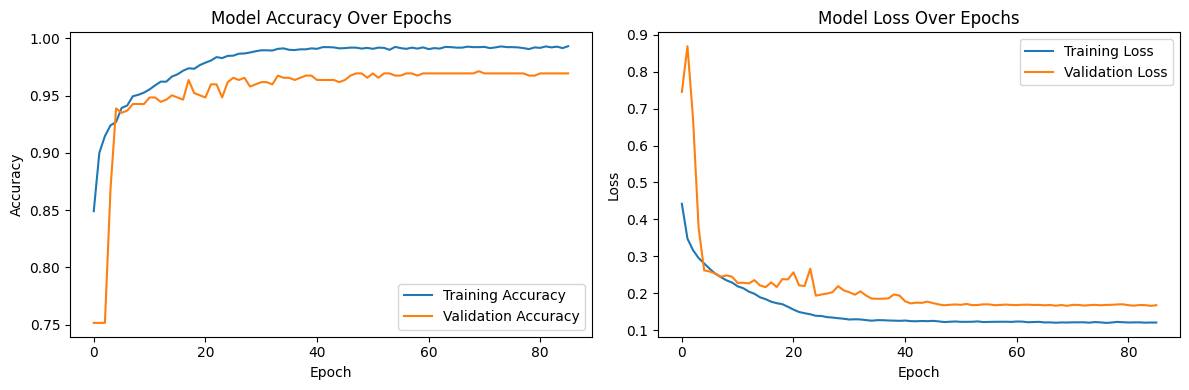

In [18]:
# Plot the validation accuracy and loss curves from training
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Figure 3** - Training and validation accuracy and loss curves over epochs for the CNN model.

During training, the model’s learning curves show that it is able to fit the task without obvious instability. Training accuracy increases steadily while training loss decreases, and the validation curves, although noisier, improve in the same direction before stabilizing. The early-stopping and checkpoint callbacks, driven by the validation PR-AUC metric, prevent the model from overfitting and select the epoch that offers the best balance between fit and generalization.

When the selected checkpoint is evaluated on the held-out test set using the _default_ decision threshold (0.5), the following metrics are obtained (F1-score computed from the reported precision and recall at threshold 0.5):

**Table 3** - Test set performance of the selected model (threshold = 0.5).

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 0.7949 |
| Loss      | 0.9249 |
| AUC       | 0.8979 |
| PR-AUC    | 0.8959 |
| Precision | 0.7529 |
| Recall    | 1.0000 |
| F1-score* | 0.8590 |

These values summarize the baseline test performance before considering alternative operating thresholds, which are analyzed in detail in the following subsections.

In [15]:
# Load the best model saved by the callback
print(f"Load the best model from: {CHECKPOINT_PATH}")
best_model = models.load_model(CHECKPOINT_PATH)

# Report metrics
results = best_model.evaluate(test_dataset_gray, verbose=2, return_dict=True)
for k,v in results.items():
	print(f"{k}: {v:.4f}")

Load the best model from: best_model_checkpoint.keras


2025-11-10 18:12:50.599576: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a1ff800c720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-10 18:12:50.599597: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-11-10 18:12:50.633992: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-10 18:12:50.706983: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500
2025-11-10 18:12:50.724383: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-10 18:12:50.911146: I e

20/20 - 6s - 308ms/step - accuracy: 0.7949 - auc: 0.8979 - loss: 0.9249 - pr_auc: 0.8959 - precision: 0.7529 - recall: 1.0000
accuracy: 0.7949
auc: 0.8979
loss: 0.9249
pr_auc: 0.8959
precision: 0.7529
recall: 1.0000


On the held-out test set, the model achieves solid baseline performance at the default decision threshold of 0.5, with accuracy of 0.7949, AUC of 0.8979 and PR-AUC of 0.8959. The detailed classification report at this threshold shows that performance is strongly asymmetric between the two classes, reflecting both the class imbalance and the recall-focused behavior of the model:

**Table 4** – Detailed test performance by class (_default_ threshold = 0.5)

| Class     | Precision | Recall | F1-score | Support |
| --------- | --------- | ------ | -------- | ------- |
| Normal    | 1.0000    | 0.4530 | 0.6235   | 234     |
| Pneumonia | 0.7529    | 1.0000 | 0.8590   | 390     |

At this operating point, all 390 pneumonia cases in the test set are correctly identified (recall 1.0000), but this comes at the cost of misclassifying 128 out of 234 Normal cases as Pneumonia, which explains the relatively low recall for the Normal class. This behavior is consistent with the clinical objective of prioritizing sensitivity to pneumonia over perfectly preserving specificity in Normal cases.

Because the retrospective screening program values missing as few pneumonia patients as possible more than avoiding outreach to healthy patients, the primary focus of evaluation is on recall and the pattern of false negatives versus false positives. To systematically explore this trade-off, we varied the classification threshold from 0.1 to 0.9 and computed accuracy, precision, recall, F1-score and confusion matrices at each point. The resulting threshold analysis, summarized in the next section, shows a wide range of thresholds where recall remains at 100% and motivates the recommended operating threshold of 0.6 used in the Conclusions.

In [16]:
# Get predictions and true labels
print("Generating predictions...")
y_true = []
y_pred_probs = []

for images, labels in test_dataset_gray:
	predictions = best_model.predict(images, verbose=0)
	y_pred_probs.extend(predictions.flatten())
	y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

print(f"\nTotal test samples: {len(y_true)}")
print(f"Pneumonia cases: {sum(y_true)} ({sum(y_true)/len(y_true)*100:.1f}%)")
print(f"Normal cases: {len(y_true) - sum(y_true)} ({(len(y_true)-sum(y_true))/len(y_true)*100:.1f}%)")

# Trade-off descriptions helper
def describe_tradeoff(threshold, recall, precision):
	if threshold <= 0.2:
		return "Very low threshold; maximize coverage"
	elif threshold <= 0.3:
		return "Maximum coverage; few missed cases"
	elif threshold <= 0.5:
		return "Strong balance"
	elif threshold <= 0.6:
		return "More conservative"
	elif threshold <= 0.8:
		return "Very selective"
	else:
		return "Extremely selective; only strongest positives"

# Test thresholds from 0.1 to 0.9 (step 0.1)
thresholds_to_test = [round(t, 1) for t in np.arange(0.1, 1.0, 0.1)]

print("\n" + "="*30)
print("THRESHOLD ANALYSIS")
print("="*30)

results = []
for threshold in thresholds_to_test:
	y_pred = (y_pred_probs >= threshold).astype(int)
	
	tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
	
	recall = tp / (tp + fn)
	precision = tp / (tp + fp) if (tp + fp) > 0 else 0
	accuracy = (tp + tn) / (tp + tn + fp + fn)
	f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
	
	results.append({
		'threshold': threshold,
		'tp': tp,
		'tn': tn,
		'fp': fp,
		'fn': fn,
		'recall': recall,
		'precision': precision,
		'accuracy': accuracy,
		'f1': f1
	})
	
	print(f"\nThreshold: {threshold}")
	print(f"  Accuracy:  {accuracy:.4f}")
	print(f"  Precision: {precision:.4f}")
	print(f"  Recall:    {recall:.4f}")
	print(f"  F1-Score:  {f1:.4f}")
	print(f"  ---")
	print(f"  True Positives (Pneumonia correctly identified):  {tp}")
	print(f"  False Negatives (Pneumonia MISSED):               {fn}")
	print(f"  False Positives (Normal incorrectly flagged):     {fp}")
	print(f"  True Negatives (Normal correctly identified):     {tn}")

# Classification Report
y_pred_default = (y_pred_probs >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred_default)

print("\nDetailed Classification Report (Threshold = 0.5):")
print(classification_report(
	y_true,
	y_pred_default,
	target_names=['Normal', 'Pneumonia'],
	digits=4
))

Generating predictions...

Total test samples: 624
Pneumonia cases: 390 (62.5%)
Normal cases: 234 (37.5%)

THRESHOLD ANALYSIS

Threshold: 0.1
  Accuracy:  0.7099
  Precision: 0.6830
  Recall:    1.0000
  F1-Score:  0.8117
  ---
  True Positives (Pneumonia correctly identified):  390
  False Negatives (Pneumonia MISSED):               0
  False Positives (Normal incorrectly flagged):     181
  True Negatives (Normal correctly identified):     53

Threshold: 0.2
  Accuracy:  0.7356
  Precision: 0.7027
  Recall:    1.0000
  F1-Score:  0.8254
  ---
  True Positives (Pneumonia correctly identified):  390
  False Negatives (Pneumonia MISSED):               0
  False Positives (Normal incorrectly flagged):     165
  True Negatives (Normal correctly identified):     69

Threshold: 0.3
  Accuracy:  0.7596
  Precision: 0.7222
  Recall:    1.0000
  F1-Score:  0.8387
  ---
  True Positives (Pneumonia correctly identified):  390
  False Negatives (Pneumonia MISSED):               0
  False Positive

2025-11-10 18:13:09.763034: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# 5. Conclusions

---

## 5.1 Key Findings

The hospital's objective is to identify patients from historical X-ray records who had pneumonia, in order to contact them for preventive care and education to reduce recurrence risk. This is a retrospective screening program for secondary prevention.

In this context, the consequences of classification errors are highly asymmetric:

* A False Negative (FN) occurs when a patient who had pneumonia is not identified. This is a high-consequence error: the patient is missed and receives no preventive outreach, leaving them at elevated risk for recurrence, complications, or hospitalization.
* A False Positive (FP) occurs when a healthy patient is incorrectly flagged. This is a low-consequence error, resulting in minor administrative overhead and a patient receiving generally useful health information.

This asymmetry dictates our optimization strategy: we must prioritize high recall (catching true pneumonia cases) over high precision. Missing vulnerable patients is far more problematic than contacting some healthy individuals. During training, model checkpoints were selected using the validation PR-AUC metric, which balances precision and recall under class imbalance, and the final operating characteristics were analyzed in detail across multiple thresholds with particular attention to recall.

The model outputs probability scores (0 to 1). The classification threshold determines the cutoff for classification:

* Higher threshold (e.g., 0.7–0.9): more conservative, fewer patients flagged, but potentially more missed pneumonia cases.
* Lower threshold (e.g., 0.1–0.3): more inclusive, more patients flagged, typically fewer or no missed pneumonia cases but more unnecessary contacts.

### 5.1.1 Results Across Different Thresholds

Based on the test set evaluation (624 total samples: 390 Pneumonia, 234 Normal), the model demonstrates the following trade-offs:

**Table 5** - Recall-precision trade-offs and error counts across decision thresholds on the test set

| Threshold | Recall (Sensitivity) | Precision | Missed Cases (FN) | Unnecessary Contacts (FP) | Trade-off                                                                        |
| :-------- | :------------------- | :-------- | :---------------- | :------------------------ | :------------------------------------------------------------------------------- |
| 0.1       | 100.0% (390/390)     | 68.3%     | 0                 | 181                       | Very low threshold; maximum coverage, many unnecessary contacts                  |
| 0.2       | 100.0% (390/390)     | 70.3%     | 0                 | 165                       | Very low threshold; maximum coverage, many unnecessary contacts                  |
| 0.3       | 100.0% (390/390)     | 72.2%     | 0                 | 150                       | Inclusive; all pneumonia cases found, high number of unnecessary contacts        |
| 0.4       | 100.0% (390/390)     | 73.2%     | 0                 | 143                       | Inclusive; all pneumonia cases found, slightly fewer unnecessary contacts        |
| 0.5       | 100.0% (390/390)     | 75.3%     | 0                 | 128                       | Balanced; all pneumonia cases found, fewer unnecessary contacts                  |
| 0.6       | 100.0% (390/390)     | 76.5%     | 0                 | 120                       | More conservative; all pneumonia cases found, fewer unnecessary contacts         |
| 0.7       | 99.7% (389/390)      | 78.9%     | 1                 | 104                       | Conservative; one missed pneumonia case, fewer unnecessary contacts              |
| 0.8       | 99.0% (386/390)      | 79.9%     | 4                 | 97                        | Very selective; a few missed cases, further reduction in unnecessary contacts    |
| 0.9       | 97.4% (380/390)      | 82.6%     | 10                | 80                        | Extremely selective; more missed cases, substantially fewer unnecessary contacts |

### 5.1.2 Interpretation of Threshold Trade-offs

Based on this data, our insights from the evaluation can be summarized as follows:

1. There is a wide plateau where recall remains at 100%.

   * For thresholds between 0.1 and 0.6, the model achieves 100% recall (390 out of 390 pneumonia cases correctly identified) regardless of the exact threshold.
   * Within this region, increasing the threshold mainly reduces unnecessary contacts. For example, raising the threshold from 0.3 to 0.6:

     * Missed cases (FN): 0 → 0 (no change; all pneumonia cases are still found).
     * Unnecessary contacts (FP): 150 → 120 (30 fewer healthy patients unnecessarily contacted).

2. Above roughly 0.7, we begin to trade recall for fewer unnecessary contacts.

   * Moving from 0.6 to 0.9:

     * Missed cases (FN): 0 → 10 (10 pneumonia patients no longer identified).
     * Unnecessary contacts (FP): 120 → 80 (40 fewer healthy patients contacted).
   * This illustrates the classic trade-off: higher thresholds reduce outreach workload but introduce a small number of missed pneumonia cases.

3. The recommended performance (threshold = 0.6) is strong and recall-focused.

   * Recall: 100.0% – the model correctly identifies 390 out of 390 pneumonia cases, missing none.
   * Precision: 76.5% – roughly three out of four flagged patients truly had pneumonia in the historical data.
   * Unnecessary contacts: 120 healthy patients (out of 234 Normal cases) would be contacted, while 114 healthy patients would not be contacted.

This recommended operating point offers full coverage of pneumonia cases on the test set, with a substantial reduction in unnecessary contacts compared to contacting everyone, while still leaving room to adjust the threshold if the hospital wishes to further reduce outreach volume at the cost of a small number of missed cases.

### 5.1.3 Confusion Matrices Across Thresholds

Figure 4 shows a grid of confusion matrices for thresholds from 0.1 to 0.9 on the test set. This visualization makes it possible to see how the balance between false positives and false negatives changes as the threshold is adjusted.

The panel labeled “Threshold = 0.6 (recommended)” corresponds to the operating point discussed above. At this threshold, all 390 pneumonia cases are correctly identified (0 missed), and among 234 normal cases, 114 are correctly not contacted and 120 are unnecessarily contacted. These counts match the values reported for threshold 0.6 in Table 3.

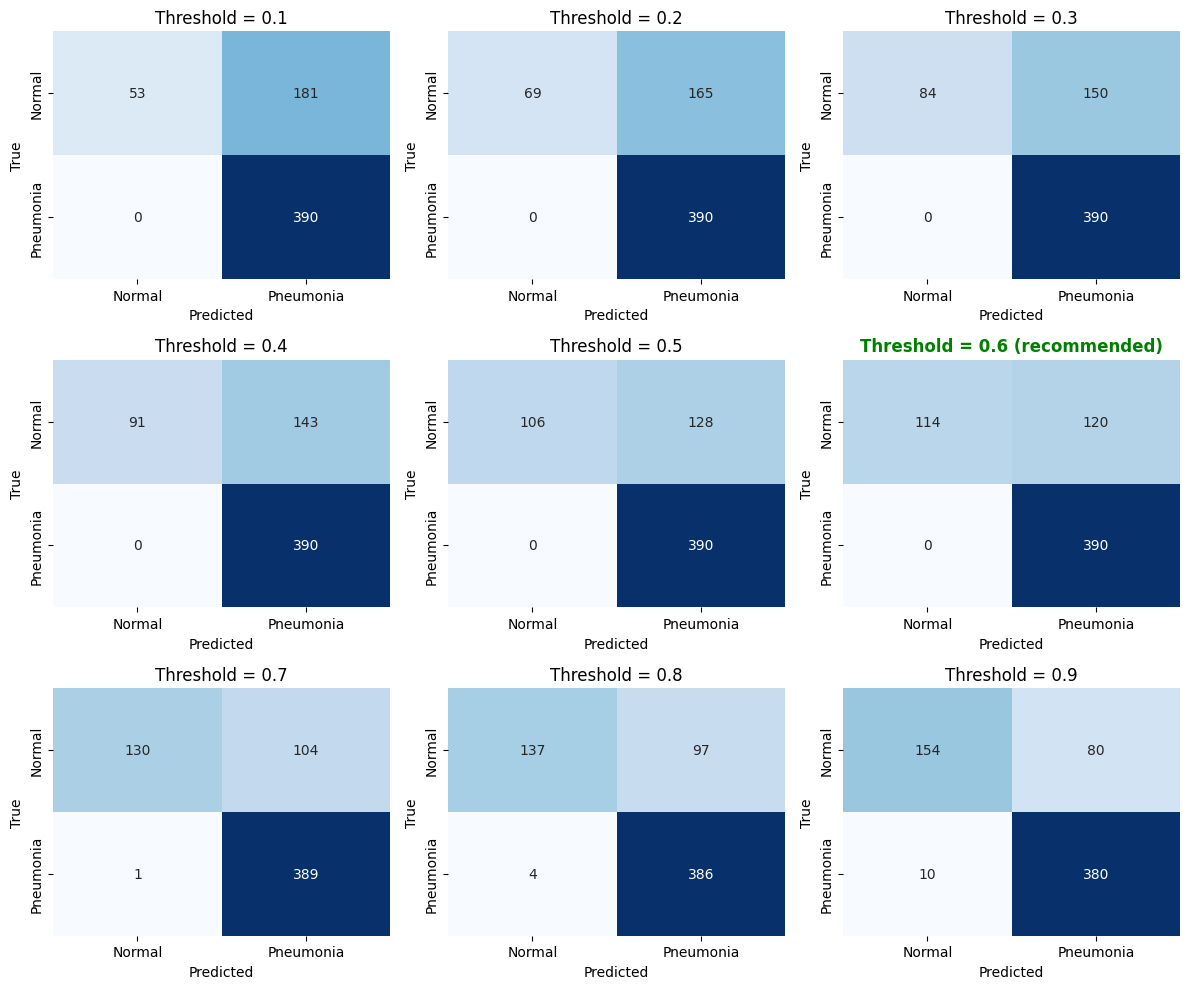

In [24]:
thresholds = [0.1 * i for i in range(1, 10)]  # 0.1, 0.2, ..., 0.9

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for ax, thr in zip(axes.ravel(), thresholds):
    y_pred_thr = (y_pred_probs >= thr).astype(int)
    cm_thr = confusion_matrix(y_true, y_pred_thr)

    sns.heatmap(
        cm_thr,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Normal', 'Pneumonia'],
        yticklabels=['Normal', 'Pneumonia'],
        ax=ax
    )

    # Mark recommended threshold (0.6)
    if abs(thr - 0.6) < 1e-6:
        ax.set_title(f'Threshold = {thr:.1f} (recommended)', fontweight='bold', color='green')
    else:
        ax.set_title(f'Threshold = {thr:.1f}')

    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

**Figure 4** - Confusion matrices on the test set for thresholds (0.6 shown as recommended threshold).

### 5.1.4 Effect of Threshold on Global Metrics

Figure 5 summarizes how recall, precision and F1-score evolve as the decision threshold varies from 0.1 to 0.9. Recall remains at 100% across a broad plateau between thresholds 0.1 and 0.6, confirming that all pneumonia cases are captured in this range regardless of the exact cutoff.

Within this plateau, increasing the threshold gradually improves precision and F1-score by reducing the number of unnecessary contacts, without sacrificing coverage of pneumonia cases. Beyond approximately 0.7, recall starts to decrease as some pneumonia cases are missed, while precision continues to improve. The vertical dashed line marks the recommended threshold of 0.6, which lies at the upper end of the full-recall region and provides the best balance between maintaining 100% recall and minimizing false positives.

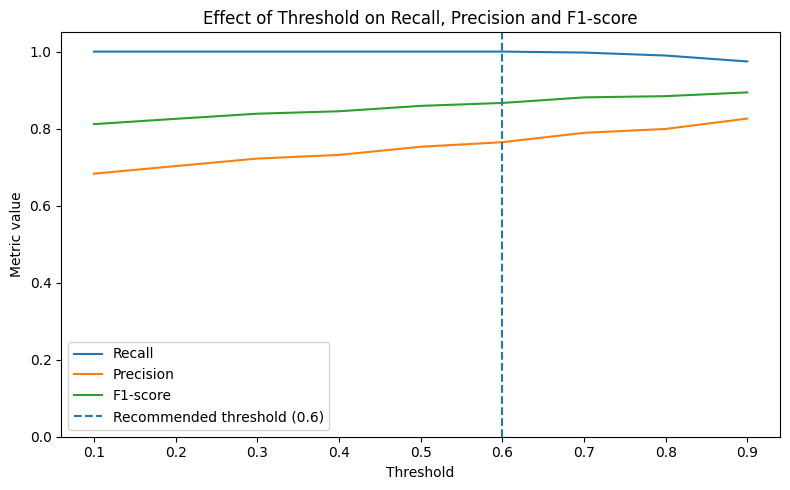

In [20]:
thresholds = [r['threshold'] for r in results]
recalls = [r['recall'] for r in results]
precisions = [r['precision'] for r in results]
f1_scores = [r['f1'] for r in results]

plt.figure(figsize=(8, 5))

plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, f1_scores, label='F1-score')

# Highlight recommended threshold
recommended_threshold = 0.6
plt.axvline(recommended_threshold, linestyle='--', label='Recommended threshold (0.6)')

plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.ylim(0, 1.05)
plt.title('Effect of Threshold on Recall, Precision and F1-score')
plt.legend()
plt.tight_layout()
plt.show()

**Figure 5** - Recall, precision and F1-score on the test set as a function of threshold.

## 5.2 Limitations

The Precision–Recall curve and the threshold–metrics plot highlight the trade-off between recall and precision when choosing the decision threshold. In general, moving along the curve means exchanging fewer missed pneumonia cases for more unnecessary contacts, or vice versa. In our specific model, there is a wide plateau (thresholds 0.1 to 0.6) where recall remains at 100%, and only beyond approximately 0.7 does recall begin to decrease.

* Lower thresholds (right side of the PR curve, higher recall): fewer missed patients but more unnecessary contacts (lower precision).
* Higher thresholds (left side of the PR curve, lower recall): fewer unnecessary contacts (higher precision) but more missed patients, once we move beyond the full-recall region.

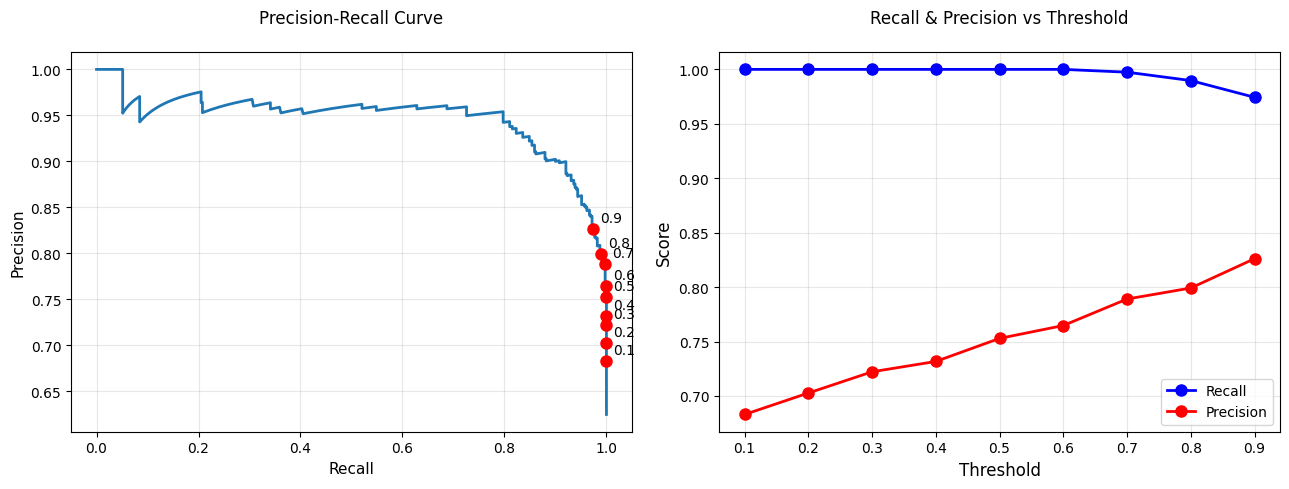

In [18]:
# Precision-Recall curve and Recall/Precision vs Threshold
plt.figure(figsize=(13, 5))

# Left plot: Precision-Recall curve
plt.subplot(1, 2, 1)
plt.plot(recall_curve, precision_curve, linewidth=2)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curve\n', fontsize=12)
plt.grid(True, alpha=0.3)

# Mark the tested thresholds (0.1 to 0.9) on the PR curve
for r in results:
	plt.plot(r['recall'], r['precision'], 'ro', markersize=8)
	plt.annotate(
		f"{r['threshold']:.1f}",
		xy=(r['recall'], r['precision']),
		xytext=(5, 5),
		textcoords='offset points'
	)

# Right plot: Recall & Precision vs Threshold
plt.subplot(1, 2, 2)
plt.plot(thresholds, recalls, 'b-o', linewidth=2, label='Recall', markersize=8)
plt.plot(thresholds, precisions, 'r-o', linewidth=2, label='Precision', markersize=8)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Recall & Precision vs Threshold\n', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 6** - Precision–recall curve and recall/precision vs threshold on the test set.

## 5.3 Recommendations

The trained model enables post-training business decisions based on resource availability and risk tolerance. Given the high cost of false negatives, the primary constraint is to operate in a region where recall remains as close to 100% as possible. On the test set, thresholds between 0.1 and 0.6 all achieve 100% recall (390 out of 390 pneumonia cases correctly identified). Among these, threshold 0.6 yields the lowest number of false positives (120), with precision of 76.5% and no missed pneumonia cases, and is therefore recommended as the standard operating point.

Based on these conclusions, a simple decision framework can be proposed, summarized in the following operational scenarios:

**Scenario 1** - Conservative outreach (limited resources)

* Threshold: **0.8**
* Strategy: Contact only higher-confidence cases, accepting a small number of missed pneumonia patients in exchange for fewer unnecessary contacts.
* Outcome: 99.0% recall (386 out of 390 pneumonia cases correctly identified, 4 missed) and 79.9% precision (97 unnecessary contacts among Normal patients).
* Use case: Situations with limited staffing or budget where reducing outreach volume is important and a small number of missed cases is acceptable.

**Scenario 2** - Balanced approach (**recommended**)

* Threshold: **0.6**
* Strategy: Maintain full coverage of pneumonia cases while reducing unnecessary contacts as much as possible within the 100%-recall region.
* Outcome: 100.0% recall (390 out of 390 pneumonia cases correctly identified, 0 missed) and 76.5% precision, with 120 unnecessary contacts and 114 Normal patients correctly not contacted.
* Use case: Standard operation for the retrospective screening program, aligning with the clinical goal of not missing pneumonia patients while keeping outreach workload manageable.

**Scenario 3** - Aggressive outreach (maximum redundancy against missed cases)

* Threshold: **0.3**
* Strategy: Use a lower threshold to flag more patients, accepting additional unnecessary contacts while still maintaining 100% recall on the test set.
* Outcome: 100.0% recall (390 out of 390 pneumonia cases correctly identified, 0 missed) and 72.2% precision, with 150 unnecessary contacts among Normal patients. Compared with the recommended threshold of 0.6, this corresponds to 30 additional healthy patients being contacted.
* Use case: Periods of elevated concern (e.g., high-risk season or suspected data drift) where the hospital prefers to err further on the side of contacting more patients rather than risk overlooking potentially vulnerable cases.

## 5.4 Summary

In this project, generalization is understood as the model’s ability to maintain very high recall (few false negatives) on unseen data, even if this comes at the cost of additional false positives, reflecting the clinical priority of not missing pneumonia cases.

On the held-out test set from the same retrospective screening population, the model achieves 100% recall across a wide range of thresholds (0.1 to 0.6). Within this full-recall region, threshold tuning allows the hospital to choose the level of outreach workload it is willing to accept. The recommended operating point at threshold 0.6 achieves 100% recall with the lowest number of false positives in this range, providing a strong balance between clinical safety and operational efficiency.

Overall, the model trained with a focus on recall provides both high performance and operational flexibility. The hospital can make informed, data-driven decisions by adjusting the classification threshold to align with clinical priorities, resource constraints and evolving policies for preventive outreach. Future work could explore data augmentation and transfer learning to potentially improve performance further while preserving a recall-focused behavior.